# Aula 6 - Laboratório 2: Otimizadores na Prática

**Objetivo:** Implementar os otimizadores Momento e Adam em nosso framework NumPy, comparar visualmente suas dinâmicas de convergência e, em seguida, replicar o experimento usando a API do PyTorch.

---

Na aula teórica, vimos que, embora o SGD seja a base da otimização em Deep Learning, ele pode ser lento e instável. Otimizadores mais avançados como o Momento e o Adam foram desenvolvidos para acelerar e estabilizar o treinamento. Hoje, vamos ver isso na prática.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Configurações de estilo para os gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 14})

## Parte 1: Estendendo nosso Framework NumPy

Vamos começar com as classes que já construímos e adicionar nossos novos otimizadores.

In [ ]:
# --- Classes do Framework (já implementadas) ---
# (Copie e cole as implementações completas da Aula 4 aqui)
class Differentiable: pass
class Layer(Differentiable): pass
class Linear(Layer): pass
class Sigmoid(Differentiable): pass
class MSELoss(Differentiable): pass
class Sequential(Layer): pass
class SGD: pass
# Presume-se que as implementações detalhadas das aulas anteriores
# serão preenchidas aqui para os exercícios a seguir. Se necessário, use parte da aula para terminar sua implementação.

### Exercício 1: Implementando os Novos Otimizadores

In [ ]:
class MomentumSGD:
    def __init__(self, model, learning_rate=0.01, momentum=0.9):
        self.model = model
        self.lr = learning_rate
        self.beta = momentum
        # Inicializar o buffer de velocidade para cada parâmetro
        self.velocities = [np.zeros_like(param) for param, grad in self.model.params()]

    def step(self):
        # TODO: Implementar o passo de atualização do SGD com Momento
        # Para cada parâmetro e gradiente:
        # 1. Atualize a velocidade: v_new = beta * v_old + grad
        # 2. Atualize o parâmetro: param = param - lr * v_new
        pass

    def zero_grad(self):
        for param, grad in self.model.params():
            grad.fill(0)

class Adam:
    def __init__(self, model, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.model = model
        self.lr = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.t = 0 # Contador de passos
        
        # Buffers para o 1º e 2º momentos
        self.m = [np.zeros_like(param) for param, grad in self.model.params()]
        self.v = [np.zeros_like(param) for param, grad in self.model.params()]

    def step(self):
        self.t += 1
        # TODO: Implementar o passo de atualização do Adam
        # Para cada parâmetro e gradiente:
        # 1. Atualize o 1º momento (m)
        # 2. Atualize o 2º momento (v)
        # 3. Corrija o viés de m e v
        # 4. Atualize o parâmetro
        pass

    def zero_grad(self):
        for param, grad in self.model.params():
            grad.fill(0)

### Exercício 2: Comparando a Convergência

In [ ]:
# Gerar dados
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)
y = y.reshape(-1, 1)

# A função train_model e as chamadas subsequentes dependem da implementação
# completa das classes do framework da Aula 4. O código abaixo é um placeholder.

def train_model(optimizer_class, **kwargs):
    # Placeholder: Implementação completa necessária aqui
    print(f"Treinando com {optimizer_class.__name__}...")
    return np.random.rand(2000) * (1/ (1 + np.arange(2000)*0.01)), None

# Treinar com cada otimizador
# loss_sgd, _ = train_model(SGD, learning_rate=0.1)
# loss_momentum, _ = train_model(MomentumSGD, learning_rate=0.1, momentum=0.9)
# loss_adam, _ = train_model(Adam, learning_rate=0.01)

# # Plotar as curvas de custo
# plt.figure(figsize=(12, 7))
# plt.plot(loss_sgd, label='SGD Padrão')
# plt.plot(loss_momentum, label='SGD com Momento')
# plt.plot(loss_adam, label='Adam')
# plt.title('Comparação da Convergência dos Otimizadores')
# plt.xlabel('Época')
# plt.ylabel('Custo (MSE)')
# plt.legend()
# plt.ylim(0, 0.3) # Limitar o eixo y para melhor visualização
# plt.grid(True)
# plt.show()

### Exercício 3: Otimizadores em PyTorch

In [ ]:
# Preparar dados para PyTorch
X_torch = torch.FloatTensor(X)
y_torch = torch.FloatTensor(y)

# Definir o modelo em PyTorch
class TorchMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 16)
        self.activation1 = nn.Sigmoid()
        self.layer2 = nn.Linear(16, 1)
        self.activation2 = nn.Sigmoid()
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.activation1(x)
        x = self.layer2(x)
        x = self.activation2(x)
        return x

# TODO: Crie uma função de treinamento similar à `train_model` acima,
# mas que use o modelo e os otimizadores do PyTorch.
# Compare os resultados. O loop de treinamento deve ser quase idêntico em sua estrutura!

### Exercício 4: Visualizando a Convergência do SGD em uma Função 2D

Para construir a intuição, vamos visualizar o caminho que o SGD percorre em uma paisagem de custo 2D. Usaremos uma função L-suave, mas com múltiplos mínimos locais para simular uma paisagem mais realista.

Máximo de 500 iterações atingido.


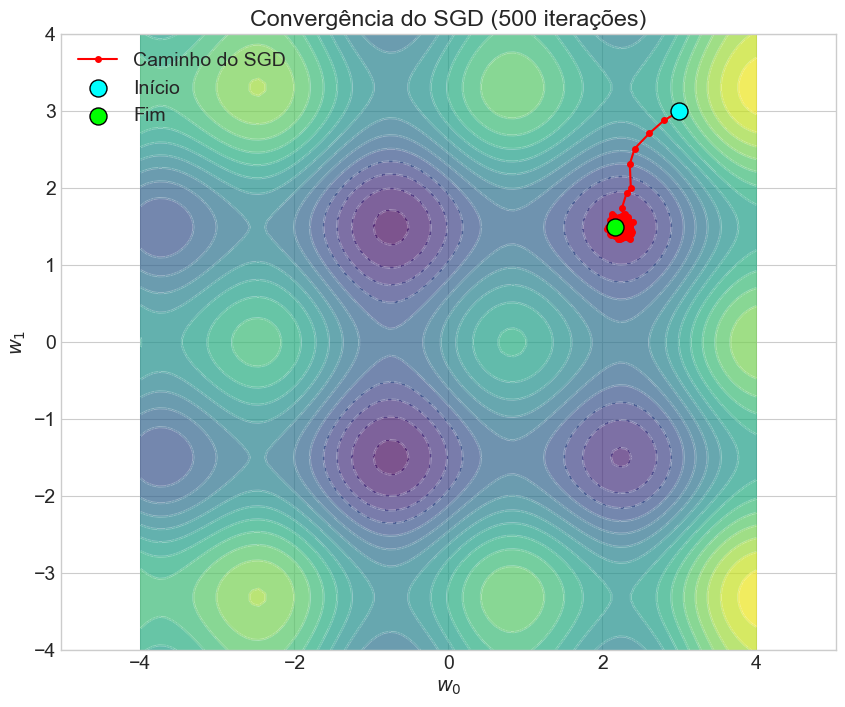

In [3]:
def cost_function_2d(w):
    """Uma função de custo 2D não-convexa, mas suave."""
    return 0.1 * (w[0]**2 + w[1]**2) + (np.sin(2 * w[0]) + np.cos(2 * w[1]))

def gradient_2d(w):
    """O gradiente analítico da função de custo."""
    grad_w0 = 0.2 * w[0] + 2 * np.cos(2 * w[0])
    grad_w1 = 0.2 * w[1] - 2 * np.sin(2 * w[1])
    return np.array([grad_w0, grad_w1])

# Hiperparâmetros para o experimento
learning_rate = 0.1
start_point = np.array([3.0, 3.0])
tolerance = 1e-4
max_iterations = 500
noise_level = 0.5 # Simula a estocasticidade

# Executando a Descida de Gradiente Estocástica
w = start_point
path = [w]
iterations = 0
for i in range(max_iterations):
    grad = gradient_2d(w)
    if np.linalg.norm(grad) < tolerance:
        print(f"Convergência alcançada após {i} iterações.")
        break
    
    # Adiciona ruído para simular o SGD
    stochastic_grad = grad + np.random.randn(2) * noise_level
    w = w - learning_rate * stochastic_grad
    path.append(w)
    iterations = i + 1

if iterations == max_iterations:
    print(f"Máximo de {max_iterations} iterações atingido.")

path = np.array(path)

# Visualização
w0_grid = np.linspace(-4, 4, 100)
w1_grid = np.linspace(-4, 4, 100)
W0, W1 = np.meshgrid(w0_grid, w1_grid)
Z = cost_function_2d([W0, W1])

plt.figure(figsize=(10, 8))
plt.contourf(W0, W1, Z, levels=20, cmap='viridis', alpha=0.7)
plt.contour(W0, W1, Z, levels=20, colors='white', alpha=0.3)
plt.plot(path[:, 0], path[:, 1], 'o-', color='red', markersize=4, label='Caminho do SGD')
plt.scatter(start_point[0], start_point[1], color='cyan', s=150, zorder=5, edgecolors='black', label='Início')
plt.scatter(w[0], w[1], color='lime', s=150, zorder=5, edgecolors='black', label='Fim')

plt.title(f"Convergência do SGD ({iterations} iterações)")
plt.xlabel("$w_0$")
plt.ylabel("$w_1$")
plt.legend()
plt.axis('equal')
plt.show()

EXPERIMENTO 1: Taxa de Aprendizado Segura
--- Análise Teórica ---
Constante de Suavidade (L): 1.0
Limite teórico para convergência da taxa de aprendizado: η < 2.0
Taxa de aprendizado escolhida (η): 0.5

A taxa de aprendizado satisfaz a condição de convergência.

--- Resultados Práticos ---
Convergência alcançada em 21 iterações.
Ponto final encontrado: w = [3.81469727e-06 3.81469727e-06]
Norma do gradiente final: 0.000005


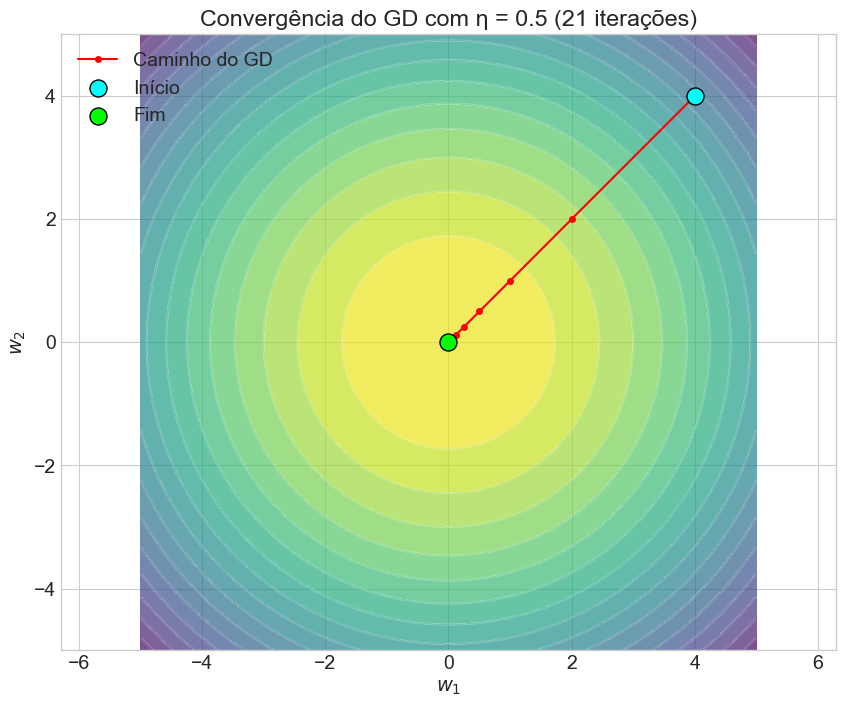


EXPERIMENTO 2: Taxa de Aprendizado Lenta
--- Análise Teórica ---
Constante de Suavidade (L): 1.0
Limite teórico para convergência da taxa de aprendizado: η < 2.0
Taxa de aprendizado escolhida (η): 0.01

A taxa de aprendizado satisfaz a condição de convergência.

--- Resultados Práticos ---
Máximo de 500 atingido. Otimização pode ter divergido.
Ponto final encontrado: w = [0.02628193 0.02628193]
Norma do gradiente final: 0.037168


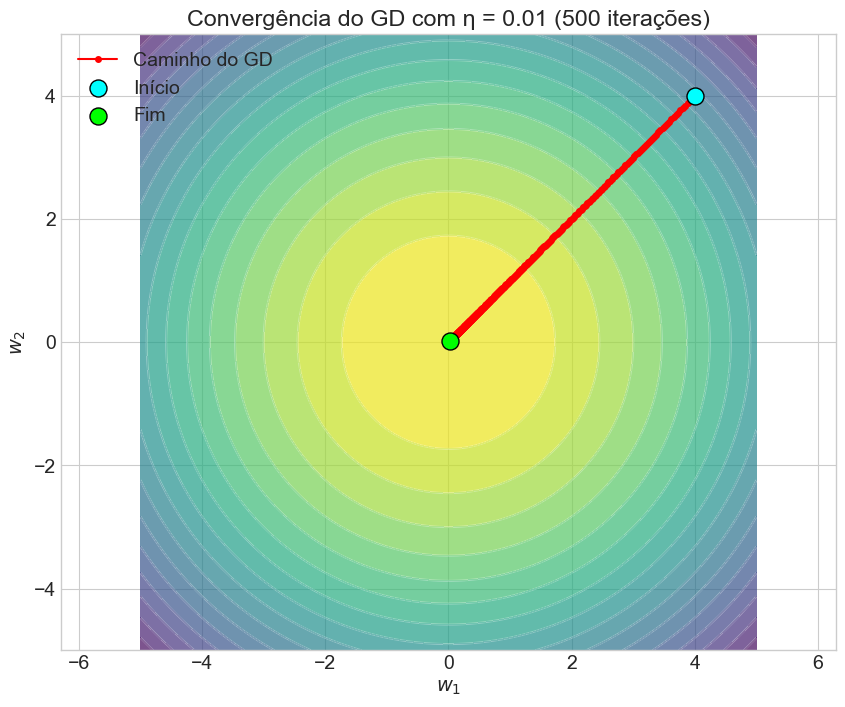


EXPERIMENTO 3: Taxa de Aprendizado Divergente
--- Análise Teórica ---
Constante de Suavidade (L): 1.0
Limite teórico para convergência da taxa de aprendizado: η < 2.0
Taxa de aprendizado escolhida (η): 2.1

Atenção: A taxa de aprendizado escolhida viola a condição de convergência. A otimização deve divergir.

--- Resultados Práticos ---
Máximo de 500 atingido. Otimização pode ter divergido.
Ponto final encontrado: w = [1.98793679e+21 1.98793679e+21]
Norma do gradiente final: 2811367165209715671040.000000


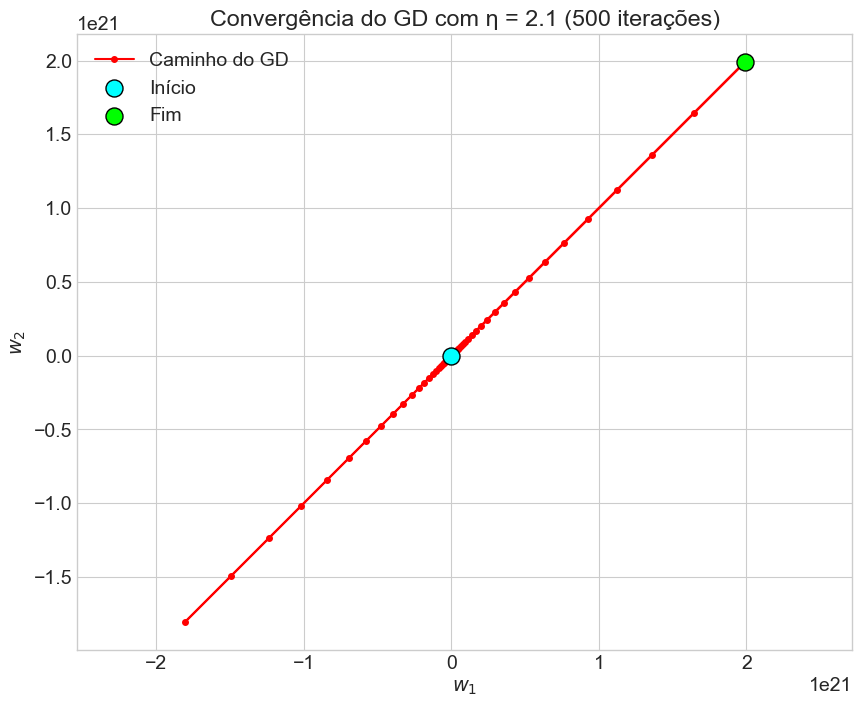

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def convergence_analysis_L_smooth(learning_rate=0.1, start_point=np.array([4.0, 4.0])):
    """
    Executa a descida de gradiente para uma função L-suave e compara
    a convergência prática com a teoria.
    """
    # --- 1. Definição da Função e Parâmetros Teóricos ---
    
    def cost_function(w):
        return 0.5 * np.sum(w**2)

    def gradient(w):
        return w

    L = 1.0 
    convergence_threshold = 2.0 / L
    
    print("--- Análise Teórica ---")
    print(f"Constante de Suavidade (L): {L}")
    print(f"Limite teórico para convergência da taxa de aprendizado: η < {convergence_threshold}")
    print(f"Taxa de aprendizado escolhida (η): {learning_rate}")
    
    if learning_rate >= convergence_threshold:
        print("\nAtenção: A taxa de aprendizado escolhida viola a condição de convergência. A otimização deve divergir.\n")
    else:
        print("\nA taxa de aprendizado satisfaz a condição de convergência.\n")

    # --- 2. Execução da Descida de Gradiente ---
    
    w = start_point
    path = [w]
    iterations = 0
    max_iterations = 500
    tolerance = 1e-5

    for i in range(max_iterations):
        grad = gradient(w)
        
        if np.linalg.norm(grad) < tolerance:
            iterations = i + 1
            break
            
        w = w - learning_rate * grad
        path.append(w)
        iterations = i + 1
    
    path = np.array(path)
    
    print("--- Resultados Práticos ---")
    if iterations < max_iterations:
        print(f"Convergência alcançada em {iterations} iterações.")
    else:
        print(f"Máximo de {max_iterations} atingido. Otimização pode ter divergido.")
    print(f"Ponto final encontrado: w = {w}")
    print(f"Norma do gradiente final: {np.linalg.norm(gradient(w)):.6f}")

    # --- 3. Visualização ---
    
    w1_grid = np.linspace(-5, 5, 100)
    w2_grid = np.linspace(-5, 5, 100)
    W1, W2 = np.meshgrid(w1_grid, w2_grid)
    
    # --- LINHA CORRIGIDA ---
    # Calculamos o custo para cada ponto na grade (W1, W2) para obter uma matriz 2D
    Z = 0.5 * (W1**2 + W2**2)
    
    plt.figure(figsize=(10, 8))
    plt.contourf(W1, W2, Z, levels=20, cmap='viridis_r', alpha=0.7)
    plt.contour(W1, W2, Z, levels=20, colors='white', alpha=0.3)
    
    plt.plot(path[:, 0], path[:, 1], 'o-', color='red', markersize=4, label='Caminho do GD')
    plt.scatter(start_point[0], start_point[1], color='cyan', s=150, zorder=5, edgecolors='black', label='Início')
    plt.scatter(w[0], w[1], color='lime', s=150, zorder=5, edgecolors='black', label='Fim')
    
    plt.title(f"Convergência do GD com η = {learning_rate} ({iterations} iterações)")
    plt.xlabel("$w_1$")
    plt.ylabel("$w_2$")
    plt.legend()
    plt.axis('equal')
    plt.show()


if __name__ == '__main__':
    # Experimento 1: Taxa de aprendizado boa, dentro do limite teórico.
    print("="*50)
    print("EXPERIMENTO 1: Taxa de Aprendizado Segura")
    print("="*50)
    convergence_analysis_L_smooth(learning_rate=0.5)
    
    # Experimento 2: Taxa de aprendizado muito pequena.
    print("\n" + "="*50)
    print("EXPERIMENTO 2: Taxa de Aprendizado Lenta")
    print("="*50)
    convergence_analysis_L_smooth(learning_rate=0.01)

    # Experimento 3: Taxa de aprendizado que viola a condição, causando divergência.
    print("\n" + "="*50)
    print("EXPERIMENTO 3: Taxa de Aprendizado Divergente")
    print("="*50)
    convergence_analysis_L_smooth(learning_rate=2.1)

# Visualizando ADAM e SGD Implementado

In [ ]:
# ===================================================================
# --- Exercício: Visualizando a Otimização em 2D ---
# ===================================================================

def cost_function_2d(w):
    """Uma função de custo 2D não-convexa com múltiplos mínimos locais."""
    return 0.1 * (w[0]**2 + w[1]**2) + (np.sin(2 * w[0]) + np.cos(2 * w[1]))

def gradient_2d(w):
    """O gradiente analítico da função de custo."""
    grad_w0 = 0.2 * w[0] + 2 * np.cos(2 * w[0])
    grad_w1 = 0.2 * w[1] - 2 * np.sin(2 * w[1])
    return np.array([grad_w0, grad_w1])

class Dummy2DNet(Layer):
    """
    Uma "rede neural" falsa que recebe as funções de custo e gradiente
    para que possamos usar nosso framework de otimização.
    """
    def __init__(self, start_point, cost_fn, grad_fn):
        # Nossos parâmetros são as coordenadas 2D
        self.theta = start_point.copy().reshape(1, 2)
        self.grad = np.zeros_like(self.theta)
        # Armazena as funções como atributos da instância
        self.cost_fn = cost_fn
        self.grad_fn = grad_fn

    def forward(self):
        # O "forward pass" calcula o custo J(theta)
        return self.cost_fn(self.theta.flatten())
    
    def backward(self):
        # O "backward pass" calcula o gradiente de J em relação a theta
        self.grad = self.grad_fn(self.theta.flatten()).reshape(1, 2)
    
    def params(self):
        return [(self.theta, self.grad)]

def visualize_optimizer_path(optimizer_class, **kwargs):
    """
    Executa a otimização de uma função 2D e plota o caminho.
    """
    start_point = np.array([3.0, 3.0])
    # Passa as funções para o construtor do modelo
    model = Dummy2DNet(start_point, cost_function_2d, gradient_2d)
    optimizer = optimizer_class(model, **kwargs)
    
    path = [start_point.copy()]
    max_iterations = 100

    for i in range(max_iterations):
        optimizer.zero_grad()
        # Neste caso simples, o backward calcula o gradiente diretamente
        model.backward() 
        optimizer.step()
        path.append(model.theta.flatten().copy())

    path = np.array(path)
    
    # --- Visualização ---
    w_grid = np.linspace(-4, 4, 100)
    W0, W1 = np.meshgrid(w_grid, w_grid)
    Z = cost_function_2d(np.array([W0, W1]))
    
    plt.figure(figsize=(10, 8))
    plt.contourf(W0, W1, Z, levels=30, cmap='viridis_r', alpha=0.8)
    plt.contour(W0, W1, Z, levels=30, colors='white', alpha=0.3)
    plt.plot(path[:, 0], path[:, 1], 'o-', color='red', markersize=4, label=f'Caminho do {optimizer_class.__name__}')
    plt.scatter(start_point[0], start_point[1], color='cyan', s=150, zorder=5, edgecolors='black', label='Início')
    plt.scatter(path[-1, 0], path[-1, 1], color='lime', s=150, zorder=5, edgecolors='black', label='Fim')
    
    plt.title(f"Caminho de Otimização ({optimizer_class.__name__})")
    plt.xlabel("$w_0$")
    plt.ylabel("$w_1$")
    plt.legend()
    plt.axis('equal')
    plt.show()

In [ ]:
# Configurações de estilo para os gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 14})

print("Visualizando o caminho de otimização para o Adam...")
# Você pode trocar 'Adam' por 'SGD' ou 'MomentumSGD' (se implementados)
# para comparar os resultados.
visualize_optimizer_path(Adam, learning_rate=0.2)